In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/vacancies_merged_prizn (2).csv", sep=',', index_col=0)

In [ ]:
df

,profession,profession_full,vacancy_description,date_published,payment_from,payment_to,experience,employment,city,company_name,company_description,vacancy_count,staff_count,catalogues,source,dms,ai,work_format,education,1с
0,Начальник отдела,Руководитель отдела сопровождения внутренней и...,"Компания ""Санкт-Петербургская биржа"" Вам предс...",2026-03-25,NaN,NaN,NaN,Полная занятость,Москва,Санкт-Петербургская биржа,NaN,NaN,NaN,NaN,scrapping,1,0,0,0,0
1,Java,Java (Senior)( ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМ...,"Компания ""ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМАЦИИ""...",2026-03-27,NaN,NaN,Более 6 лет,Полная занятость,Москва,ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМАЦИИ,NaN,NaN,NaN,NaN,scrapping,1,0,0,0,0
2,Специалист,Middle+ AQA специалист,"Компания ""Компания Ритейл Сервис"" Мы - аккреди...",2026-03-26,140000.0,180000.0,NaN,Полная занятость,Барнаул,Компания Ритейл Сервис,NaN,NaN,NaN,NaN,scrapping,0,0,2,0,0
3,Технолог,Технолог( АКРИХИН ),"Компания ""АКРИХИН"" Обязанности: Обеспечивать ...",2026-03-25,NaN,NaN,NaN,Полная занятость,Старая Купавна,АКРИХИН,NaN,NaN,NaN,NaN,scrapping,1,0,0,2,0
4,Project manager,Project Manager Game Dev( Beresnev Games ),"Компания ""Beresnev Games"" Мы в поиске Project ...",2026-03-26,NaN,NaN,NaN,Полная занятость,Москва,Beresnev Games,NaN,NaN,NaN,NaN,scrapping,0,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30862,Практикант / стажёр Документовед,Практикант / стажёр Документовед,ГНЦ РФ АО «ВНИИНМ» разрабатывает конструкционн...,2026-04-08,0.0,0.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",Росатом,"Российская государственная корпорация, объедин...",3.0,менее 50,"[{'id': 1, 'title': 'Административная работа, ...",api,1,0,0,0,0
30863,Технический специалист/ Системный администратор,Технический специалист/ Системный администратор,"Обязанности:\n• Установка, обновление и админи...",2026-04-08,80000.0,100000.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",ГБОУ Школа № 657,"Наша Школа - это пространство возможностей, тв...",1.0,менее 50,"[{'id': 33, 'title': 'IT, Интернет, связь, тел...",api,0,0,0,0,0
30864,Стажер в IT отдел,Стажер в IT отдел,Здесь занимаются поддержкой IT-платформ и их р...,2026-04-08,0.0,0.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",Добрый,Ведущий российский бренд безалкогольных напитк...,0.0,более 5000,"[{'id': 33, 'title': 'IT, Интернет, связь, тел...",api,1,0,1,0,0
30865,Сотрудник технической поддержки,Сотрудник технической поддержки,"Добрый день!\nМы компания Lasertech, занимаемс...",2026-04-07,80000.0,0.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",Lasertech,Lasertech — один из ведущих игроков на рынке п...,1.0,менее 50,"[{'id': 33, 'title': 'IT, Интернет, связь, тел...",api,0,0,0,1,1


Для кластеризации мы исключаем признаки, которые никак не связаны с категорией профессии. Это source, как ни странно company_name, company_description. Это нам не поможет так как от отрасли компании могут не зависеть it вакансии, которые ей нужны. Staff_count, vacancy_count и date_published не влияют на содержание профессии.

Плюс мы исключаем profession и profession_full, потому что нам важно получить объективную группировку вакансий по профессиям на основе признаков.

In [ ]:
df_useful = df[['payment_from', 'payment_to', 'experience',
    'employment', 'city', 'catalogues', 'dms', 'ai', 'work_format', 'education', '1с']].copy()

Для кластеризации лучше one-hot encoding, чтобы исключить линейную связь. Поэтому обработаем признаки.

Обработка зарплаты

In [ ]:
import numpy as np

In [ ]:
df_useful['payment_from_clean'] = df_useful['payment_from']
df_useful['payment_to_clean'] = df_useful['payment_to']

# если payment_to меньше 1000 & payment_from > 1000, то payment_to * 1000
mask = (df_useful['payment_to'] < 1000) & (df_useful['payment_from'] > 1000)
df_useful.loc[mask, 'payment_to_clean'] = df_useful.loc[mask, 'payment_to'] * 1000

# если оба < 1000, то payment_from * 1000 + payment_to & payment_to = null
mask = (df_useful['payment_from'] < 1000) & (df_useful['payment_to'] < 1000)
df_useful.loc[mask, 'payment_from_clean'] = df_useful.loc[mask, 'payment_from'] * 1000
df_useful.loc[mask, 'payment_to_clean'] = np.nan

# 0 = null
df_useful.loc[df_useful['payment_from_clean'] < 10, 'payment_from_clean'] = np.nan
df_useful.loc[df_useful['payment_to_clean'] < 10, 'payment_to_clean'] = np.nan

In [ ]:
df_useful = df_useful.drop(columns=['payment_from', 'payment_to'])

Признак experience необходимо обработать, чтобы из категориального он стал порядковым.

In [ ]:
df_useful['experience'].unique()

array([nan, 'Более 6 лет', 'Нет опыта', 'Более 1 года', 'Более 3 лет',
       'Более 2 лет'], dtype=object)

In [ ]:
df_useful['experience'] = df_useful['experience'].fillna('Не указано')

df_useful = pd.get_dummies(df_useful, columns=['experience'])

Аналогичная обработка employment

In [ ]:
df_useful['employment'].unique()

array(['Полная занятость', 'Временная работа', 'Частичная занятость',
       'Удаленная работа', 'Сменный график', 'Стажировка', 'Подработка',
       nan], dtype=object)

In [ ]:
df_useful['employment'] = df_useful['employment'].fillna('Не указано')

df_useful = pd.get_dummies(df_useful, columns=['employment'])

Обрабытваем city. В одной части датафрейма город записан словом, в другой части в виде json.

In [ ]:
df_useful['city'].iloc[30862]

"{'id': 4, 'title': 'Москва', 'declension': 'в Москве', 'hasMetro': True, 'genitive': 'Москвы'}"

In [ ]:
import ast # https://habr.com/ru/companies/piter/articles/493424/

def extract_city_name(city_value):
    if pd.isna(city_value):
        return np.nan
    if str(city_value).startswith('{'):
          city_dict = ast.literal_eval(city_value)
          return city_dict.get('title', np.nan)
    else:
          return city_value

df_useful['city_name'] = df_useful['city'].apply(extract_city_name)

In [ ]:
df_useful = df_useful.drop(columns=['city'])

In [ ]:
df_useful['city_name'].nunique()

1267

Странно проводить OHE на 1267 разных значениях. Но даже если мы условно проведём, а потом сожмём с помощью PCA, то у нас скорее всего останутся только Москва и Санкт-Петербург. А все остальные города уйдут.

In [ ]:
city_counts = df_useful['city_name'].value_counts()

min_count = 5
top_cities = city_counts[city_counts >= min_count].index.tolist() #убираем те, которые встречаются меньше 5 раз

df_useful['city_grouped'] = df_useful['city_name'].apply(
    lambda x: x if x in top_cities else 'Другие'
)

df_useful.drop(columns=['city_name'])
print(df_useful['city_grouped'].nunique())

376


In [ ]:
df_useful = pd.get_dummies(df_useful, columns=['city_grouped'])

Обрабатываем catalogues. Что это за поле?

In [ ]:
df_useful['catalogues'].iloc[30862]

"[{'id': 1, 'title': 'Административная работа, секретариат, АХО', 'key': 1, 'positions': [{'id': 4, 'title': 'Делопроизводство', 'key': 4}, {'id': 10, 'title': 'Начало карьеры, мало опыта', 'key': 10}, {'id': 631, 'title': 'Ввод данных, систематизация', 'key': 631}]}, {'id': 33, 'title': 'IT, Интернет, связь, телеком', 'key': 33, 'positions': [{'id': 61, 'title': 'Начало карьеры, мало опыта', 'key': 61}]}]"

По сути это более подробное описание сферы вакансии. Можем его распарсить, чтобы мы могли лучше описывать профессию. Так как хотим с помощью кластеризации разделять профессии, нет смысла смотреть на title, так как он описывает отрасль компании.

In [ ]:
exclude_positions = {'Начало карьеры, мало опыта', 'Без опыта', 'Студенты, стажировка'}

def extract_industries(ind_value):
    if pd.isna(ind_value):
        return np.nan
    if str(ind_value).startswith('['):
          ind_dict = ast.literal_eval(ind_value)
          positions = []
          for item in ind_dict:
            for pos in item['positions']:
              pos_title = pos.get('title')
              if pos_title not in exclude_positions:
                positions.append(pos_title)
          return positions if positions else np.nan
    else:
          return ind_value

df_useful['catalogues_name'] = df_useful['catalogues'].apply(extract_industries)

In [ ]:
df_useful = df_useful.drop(columns='catalogues')

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mask = df_useful['catalogues_name'].isna()
df_useful.loc[mask, 'catalogues_name'] = df_useful.loc[mask, 'catalogues_name'].apply(lambda x: [])

mlb = MultiLabelBinarizer()
pos_matrix = mlb.fit_transform(df_useful['catalogues_name'])
pos_dummies = pd.DataFrame(pos_matrix, columns=mlb.classes_, index=df_useful.index)

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MultiLabelBinarizer.html

Оставляем только ту информацию о вакансии, которая встречается больше пяти раз

In [ ]:
min_count = 5
pos_counts = pos_dummies.sum(axis=0)
keep_cols = pos_counts[pos_counts > min_count].index.tolist()
pos_dummies_filtered = pos_dummies[keep_cols]

In [ ]:
pos_dummies_filtered = pos_dummies_filtered.add_prefix('pos_')

df_useful = pd.concat([df_useful, pos_dummies_filtered], axis=1)

In [ ]:
df_useful = df_useful.drop(columns='catalogues_name')

Обрабатываем work_format с помощью OHE

In [ ]:
df_useful['work_format'].unique()

array([0, 2, 1])

In [ ]:
df_useful['work_format'] = df_useful['work_format'].fillna('Не указано')

df_useful = pd.get_dummies(df_useful, columns=['work_format'])

Обрабатываем education с помощью OHE

In [ ]:
df_useful['education'].unique()

array([0, 2, 1])

In [ ]:
df_useful['education'] = df_useful['education'].fillna('Не указано')

df_useful = pd.get_dummies(df_useful, columns=['education'])

Итоговый список колонок

In [ ]:
df_useful = df_useful.drop(columns=['city_name'])

In [ ]:
df_useful.columns.tolist()

['dms',
 'ai',
 '1с',
 'payment_from_clean',
 'payment_to_clean',
 'experience_Более 1 года',
 'experience_Более 2 лет',
 'experience_Более 3 лет',
 'experience_Более 6 лет',
 'experience_Не указано',
 'experience_Нет опыта',
 'employment_Временная работа',
 'employment_Не указано',
 'employment_Подработка',
 'employment_Полная занятость',
 'employment_Сменный график',
 'employment_Стажировка',
 'employment_Удаленная работа',
 'employment_Частичная занятость',
 'city_grouped_Абакан',
 'city_grouped_Адлер',
 'city_grouped_Азов',
 'city_grouped_Александров',
 'city_grouped_Алексин',
 'city_grouped_Альметьевск',
 'city_grouped_Амурск',
 'city_grouped_Анадырь',
 'city_grouped_Анапа',
 'city_grouped_Ангарск',
 'city_grouped_Апрелевка',
 'city_grouped_Арзамас',
 'city_grouped_Армавир',
 'city_grouped_Арсеньев',
 'city_grouped_Артем',
 'city_grouped_Артём',
 'city_grouped_Архангельск',
 'city_grouped_Асбест',
 'city_grouped_Астрахань',
 'city_grouped_Ачинск',
 'city_grouped_Аша',
 'city_group

In [ ]:
len(df_useful.columns.tolist())

615

Слишком больше количество колонок получилось, нужно применить PCA. Применим его к городам и информации о вакансиях по отдельности.

In [ ]:
city_cols = [c for c in df_useful.columns if c.startswith('city_grouped_')]
pos_cols = [c for c in df_useful.columns if c.startswith('pos_')]
other_cols = [c for c in df_useful.columns if c not in city_cols and c not in pos_cols]

PCA для городов

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_city = StandardScaler()
X_city_scaled = scaler_city.fit_transform(df_useful[city_cols])

pca_city = PCA(n_components=30, random_state=42)
city_pca = pca_city.fit_transform(X_city_scaled)

city_pca_df = pd.DataFrame(
    city_pca,
    columns=[f'city_pca_{i+1}' for i in range(city_pca.shape[1])],
    index=df_useful.index
)

In [449]:
city_pca_df.head()

,city_pca_1,city_pca_2,city_pca_3,city_pca_4,city_pca_5,city_pca_6,city_pca_7,city_pca_8,city_pca_9,city_pca_10,...,city_pca_21,city_pca_22,city_pca_23,city_pca_24,city_pca_25,city_pca_26,city_pca_27,city_pca_28,city_pca_29,city_pca_30
0,1.627181,0.113681,0.051853,0.013272,0.000354,0.010472,0.009889,0.001044,0.005215,0.003937,...,0.000294,0.002541,0.000600,0.000297,-0.000576,-0.000857,0.001526,0.000527,0.000318,-0.000582
1,1.627181,0.113681,0.051853,0.013272,0.000354,0.010472,0.009889,0.001044,0.005215,0.003937,...,0.000294,0.002541,0.000600,0.000297,-0.000576,-0.000857,0.001526,0.000527,0.000318,-0.000582
2,-0.752898,-0.506934,-0.494408,-0.294056,-0.011110,-0.355487,-0.408385,-0.065263,-0.347241,-0.312094,...,-0.090379,-0.871721,-0.302591,-0.164487,0.338293,0.558482,-1.200022,-0.561803,-0.387490,0.816828
3,-0.743483,-0.484055,-0.453084,-0.244947,-0.008677,-0.272913,-0.298919,-0.042103,-0.219063,-0.184134,...,-0.024631,-0.219096,-0.056313,-0.028371,0.055540,0.083972,-0.153547,-0.054842,-0.033504,0.062096
4,1.627181,0.113681,0.051853,0.013272,0.000354,0.010472,0.009889,0.001044,0.005215,0.003937,...,0.000294,0.002541,0.000600,0.000297,-0.000576,-0.000857,0.001526,0.000527,0.000318,-0.000582


https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-with-python/

PCA для информации о вакансиях

In [ ]:
scaler_pos = StandardScaler()
X_pos_scaled = scaler_pos.fit_transform(df_useful[pos_cols])

pca_pos = PCA(n_components=30, random_state=42)
pos_pca = pca_pos.fit_transform(X_pos_scaled)

pos_pca_df = pd.DataFrame(
    pos_pca,
    columns=[f'pos_pca_{i+1}' for i in range(pos_pca.shape[1])],
    index=df_useful.index
)

In [450]:
pos_pca_df.head()

,pos_pca_1,pos_pca_2,pos_pca_3,pos_pca_4,pos_pca_5,pos_pca_6,pos_pca_7,pos_pca_8,pos_pca_9,pos_pca_10,...,pos_pca_21,pos_pca_22,pos_pca_23,pos_pca_24,pos_pca_25,pos_pca_26,pos_pca_27,pos_pca_28,pos_pca_29,pos_pca_30
0,-0.177444,-0.445855,-0.072941,-0.260602,-0.186311,-0.108255,-0.203606,-0.054728,-0.100376,-0.107684,...,0.068196,-0.119152,-0.004161,0.056995,0.026518,0.00769,-0.037496,-0.007449,-0.062298,0.03028
1,-0.177444,-0.445855,-0.072941,-0.260602,-0.186311,-0.108255,-0.203606,-0.054728,-0.100376,-0.107684,...,0.068196,-0.119152,-0.004161,0.056995,0.026518,0.00769,-0.037496,-0.007449,-0.062298,0.03028
2,-0.177444,-0.445855,-0.072941,-0.260602,-0.186311,-0.108255,-0.203606,-0.054728,-0.100376,-0.107684,...,0.068196,-0.119152,-0.004161,0.056995,0.026518,0.00769,-0.037496,-0.007449,-0.062298,0.03028
3,-0.177444,-0.445855,-0.072941,-0.260602,-0.186311,-0.108255,-0.203606,-0.054728,-0.100376,-0.107684,...,0.068196,-0.119152,-0.004161,0.056995,0.026518,0.00769,-0.037496,-0.007449,-0.062298,0.03028
4,-0.177444,-0.445855,-0.072941,-0.260602,-0.186311,-0.108255,-0.203606,-0.054728,-0.100376,-0.107684,...,0.068196,-0.119152,-0.004161,0.056995,0.026518,0.00769,-0.037496,-0.007449,-0.062298,0.03028


In [ ]:
other_columns = df_useful[other_cols]
df_features = pd.concat([other_columns, city_pca_df, pos_pca_df], axis=1)

In [ ]:
len(df_features.columns.tolist())

85

Работаем с налами и стандартизируем перед кластеризацией

In [416]:
print(np.isnan(df_features).sum().sum())

nan_cols = np.isnan(df_features).any(axis=0)
print(df_features.columns[nan_cols].tolist())

38371
['payment_from_clean', 'payment_to_clean']


In [405]:
df_features_filled = df_features.copy()
df_features_filled['profession'] = df['profession']

median_from_map = df_features_filled.groupby('profession')['payment_from_clean'].median()
median_to_map = df_features_filled.groupby('profession')['payment_to_clean'].median()

df_features_filled['payment_from_clean'] = df_features_filled['payment_from_clean'].fillna(df_features_filled['profession'].map(median_from_map))
df_features_filled['payment_to_clean'] = df_features_filled['payment_to_clean'].fillna(df_features_filled['profession'].map(median_to_map))

df_features_filled['payment_from_clean'] = df_features_filled['payment_from_clean'].fillna(df_features_filled['payment_from_clean'].median())
df_features_filled['payment_to_clean'] = df_features_filled['payment_to_clean'].fillna(df_features_filled['payment_to_clean'].median())

In [407]:
df_features_filled = df_features_filled.drop(columns=['profession'])

In [409]:
scaler_final = StandardScaler()
df_features_scaled = scaler_final.fit_transform(df_features_filled)

Мы не знаем точного числа кластеров, плюс предполагаем, что кластеры не будут линейно делимы. Стоит учесть, что нас достаточно шумные данные, информация от разных работадателей между собой не сходится. Из-за этого лучше использовать HDBSCAN.

https://dinhanhthi.com/note/dbscan-hdbscan-clustering/ - более подробное описание разницы

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html

In [425]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=10,
    cluster_selection_epsilon=0.7
)
clusters = clusterer.fit_predict(df_features_scaled)

df['cluster'] = clusters

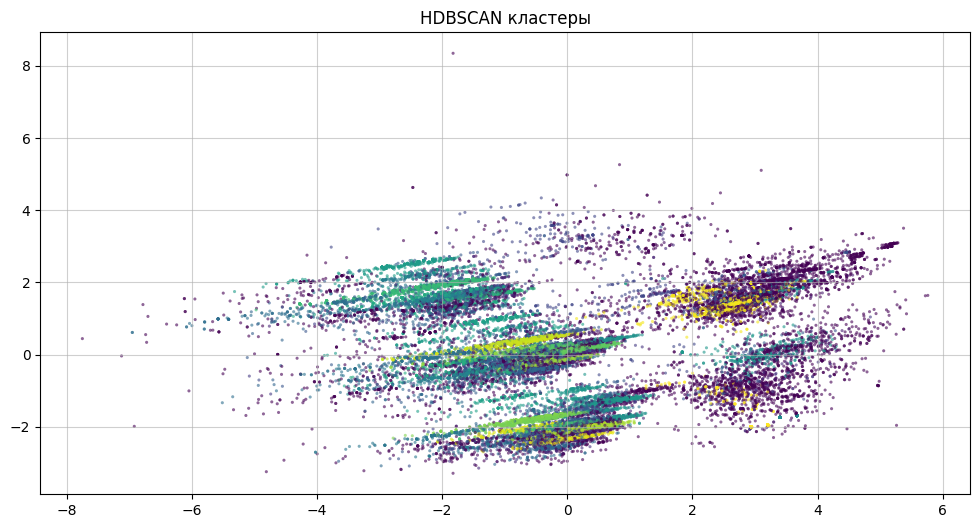

In [447]:
import matplotlib.pyplot as plt

pca_plot = PCA(n_components=2, random_state=42)
pca_data = pca_plot.fit_transform(df_features_scaled)

plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=clusters,
    s=5,
    alpha=0.6,
    edgecolors='none'
)
plt.title('HDBSCAN кластеры')
plt.grid(alpha=0.6)
plt.show()

In [445]:
profile_cols = ['payment_from_clean', 'payment_to_clean', 'dms', 'ai', '1с',
                'work_format_0', 'work_format_1', 'work_format_2',
                'education_0', 'education_1', 'education_2']

df_features['cluster'] = clusters
cluster_profile = df_features.groupby('cluster')[profile_cols].mean().round(2)
print(cluster_profile)

         payment_from_clean  payment_to_clean   dms    ai    1с  \
cluster                                                           
-1                 98245.59         109603.90  0.36  0.06  0.15   
 0                100545.80         106181.82  0.41  0.07  0.13   
 1                 91975.71          88795.14  0.35  0.12  0.11   
 2                113611.82         110105.84  0.30  0.06  0.19   
 3                 99971.16         105787.50  0.46  0.01  0.13   
 4                 87897.18         113000.00  0.23  0.06  0.16   
 5                101347.45          99644.55  0.24  0.03  0.22   
 6                 83729.66         103270.07  0.26  0.02  0.14   
 7                110783.75         132307.25  0.36  0.08  0.12   
 8                116488.64         137565.93  0.38  0.05  0.15   
 9                100491.89         115848.21  0.31  0.08  0.25   
 10                57693.12          91032.61  0.05  0.13  0.07   
 11               105859.48         125713.61  0.25  0.04  0.1